# Exploratory Data Analysist (EDA) Udemy Course

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/udemy_courses_dataset.csv'
df = pd.read_csv(path)
# Melihat 5 data pertama
df.head()

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18T20:58:58Z,Business Finance
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39.0,2017-03-09T16:34:20Z,Business Finance
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,2017-05-30T20:07:24Z,Business Finance
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,2016-12-13T14:57:18Z,Business Finance


## 2. Data Inspections

### 2.1 Melihat dimensi data

In [ ]:
df.shape

(3678, 12)

### 2.2 Melihat kolom atau field yang ada pada data

In [ ]:
df.columns

Index(['course_id', 'course_title', 'url', 'is_paid', 'price',
       'num_subscribers', 'num_reviews', 'num_lectures', 'level',
       'content_duration', 'published_timestamp', 'subject'],
      dtype='object')

### 2.3 Melihat apakah data memiliki nilai kosong

In [ ]:
missing_values = df.isnull().sum()
missing_values

,0
course_id,0
course_title,0
url,0
is_paid,0
price,0
num_subscribers,0
num_reviews,0
num_lectures,0
level,0
content_duration,0


### 2.4.Melihat apakah ada data yang duplikat

In [ ]:
duplicate_values = df.duplicated().sum()
print(f"Jumlah duplikat value pada data: {duplicate_values}")

Jumlah duplikat value pada data: 6


In [ ]:
df[df.duplicated(keep=False)]

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
453,837322,Essentials of money value: Get a financial Life !,https://www.udemy.com/essentials-of-money-value/,True,20,0,0,20,All Levels,0.616667,2016-05-16T18:28:30Z,Business Finance
454,1157298,Introduction to Forex Trading Business For Beg...,https://www.udemy.com/introduction-to-forex-tr...,True,20,0,0,27,Beginner Level,1.500000,2017-04-23T16:19:01Z,Business Finance
463,1084454,CFA Level 2- Quantitative Methods,https://www.udemy.com/cfa-level-2-quantitative...,True,40,0,0,35,All Levels,5.500000,2017-07-02T14:29:35Z,Business Finance
778,1035638,Understanding Financial Statements,https://www.udemy.com/understanding-financial-...,True,25,0,0,10,All Levels,1.000000,2016-12-15T14:56:17Z,Business Finance
787,837322,Essentials of money value: Get a financial Life !,https://www.udemy.com/essentials-of-money-value/,True,20,0,0,20,All Levels,0.616667,2016-05-16T18:28:30Z,Business Finance
788,1157298,Introduction to Forex Trading Business For Beg...,https://www.udemy.com/introduction-to-forex-tr...,True,20,0,0,27,Beginner Level,1.500000,2017-04-23T16:19:01Z,Business Finance
894,1035638,Understanding Financial Statements,https://www.udemy.com/understanding-financial-...,True,25,0,0,10,All Levels,1.000000,2016-12-15T14:56:17Z,Business Finance
1100,1084454,CFA Level 2- Quantitative Methods,https://www.udemy.com/cfa-level-2-quantitative...,True,40,0,0,35,All Levels,5.500000,2017-07-02T14:29:35Z,Business Finance
1234,185526,MicroStation - Células,https://www.udemy.com/microstation-celulas/,True,20,0,0,9,Beginner Level,0.616667,2014-04-15T21:48:55Z,Graphic Design
1473,185526,MicroStation - Células,https://www.udemy.com/microstation-celulas/,True,20,0,0,9,Beginner Level,0.616667,2014-04-15T21:48:55Z,Graphic Design


### 2.5 Melihat deskripsi dari data

In [ ]:
df.describe()

,course_id,price,num_subscribers,num_reviews,num_lectures,content_duration
count,3.678000e+03,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000
mean,6.759720e+05,66.049483,3197.150625,156.259108,40.108755,4.094517
std,3.432732e+05,61.005755,9504.117010,935.452044,50.383346,6.053840
min,8.324000e+03,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.076925e+05,20.000000,111.000000,4.000000,15.000000,1.000000
50%,6.879170e+05,45.000000,911.500000,18.000000,25.000000,2.000000
75%,9.613555e+05,95.000000,2546.000000,67.000000,45.750000,4.500000
max,1.282064e+06,200.000000,268923.000000,27445.000000,779.000000,78.500000


## 3. Data Preprocessing

### 3.1 Menghilangkan nilai duplikat

In [ ]:
df_cleaned = df.drop_duplicates()

# Mengecek ulang apakah masih ada data yang duplikat
print(f"Jumlah duplikat value setelah di proses: {df_cleaned.duplicated().sum()}")

Jumlah duplikat value setelah di proses: 0


### 3.2 Feature Engineering

Menambahkan kolom tahun dan bulan berdasarkan kolom published timestamps

In [ ]:
df_cleaned['published_timestamp'] = pd.to_datetime(df_cleaned['published_timestamp'])

df_cleaned['year'] = df_cleaned['published_timestamp'].dt.year
df_cleaned['month'] = df_cleaned['published_timestamp'].dt.month

df_cleaned['month_name'] = df_cleaned['published_timestamp'].dt.strftime('%B')

df_cleaned


<ipython-input-12-b41595ba3780>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['published_timestamp'] = pd.to_datetime(df_cleaned['published_timestamp'])
<ipython-input-12-b41595ba3780>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['year'] = df_cleaned['published_timestamp'].dt.year
<ipython-input-12-b41595ba3780>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,year,month,month_name
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18 20:58:58+00:00,Business Finance,2017,1,January
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39.0,2017-03-09 16:34:20+00:00,Business Finance,2017,3,March
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19 19:26:30+00:00,Business Finance,2016,12,December
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,2017-05-30 20:07:24+00:00,Business Finance,2017,5,May
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,2016-12-13 14:57:18+00:00,Business Finance,2016,12,December
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3673,775618,Learn jQuery from Scratch - Master of JavaScri...,https://www.udemy.com/easy-jquery-for-beginner...,True,100,1040,14,21,All Levels,2.0,2016-06-14 17:36:46+00:00,Web Development,2016,6,June
3674,1088178,How To Design A WordPress Website With No Codi...,https://www.udemy.com/how-to-make-a-wordpress-...,True,25,306,3,42,Beginner Level,3.5,2017-03-10 22:24:30+00:00,Web Development,2017,3,March
3675,635248,Learn and Build using Polymer,https://www.udemy.com/learn-and-build-using-po...,True,40,513,169,48,All Levels,3.5,2015-12-30 16:41:42+00:00,Web Development,2015,12,December
3676,905096,CSS Animations: Create Amazing Effects on Your...,https://www.udemy.com/css-animations-create-am...,True,50,300,31,38,All Levels,3.0,2016-08-11 19:06:15+00:00,Web Development,2016,8,August


Menambahkan kolom revenue dengan melakukan perkalian antara kolom subscriber dan price

In [ ]:
df_cleaned["revenue"] = df_cleaned["price"] * df_cleaned["num_subscribers"]
df_cleaned

<ipython-input-13-8670c93919e1>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["revenue"] = df_cleaned["price"] * df_cleaned["num_subscribers"]


,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,year,month,month_name,revenue
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18 20:58:58+00:00,Business Finance,2017,1,January,429400
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39.0,2017-03-09 16:34:20+00:00,Business Finance,2017,3,March,209400
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19 19:26:30+00:00,Business Finance,2016,12,December,97830
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,2017-05-30 20:07:24+00:00,Business Finance,2017,5,May,232845
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,2016-12-13 14:57:18+00:00,Business Finance,2016,12,December,255200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3673,775618,Learn jQuery from Scratch - Master of JavaScri...,https://www.udemy.com/easy-jquery-for-beginner...,True,100,1040,14,21,All Levels,2.0,2016-06-14 17:36:46+00:00,Web Development,2016,6,June,104000
3674,1088178,How To Design A WordPress Website With No Codi...,https://www.udemy.com/how-to-make-a-wordpress-...,True,25,306,3,42,Beginner Level,3.5,2017-03-10 22:24:30+00:00,Web Development,2017,3,March,7650
3675,635248,Learn and Build using Polymer,https://www.udemy.com/learn-and-build-using-po...,True,40,513,169,48,All Levels,3.5,2015-12-30 16:41:42+00:00,Web Development,2015,12,December,20520
3676,905096,CSS Animations: Create Amazing Effects on Your...,https://www.udemy.com/css-animations-create-am...,True,50,300,31,38,All Levels,3.0,2016-08-11 19:06:15+00:00,Web Development,2016,8,August,15000


## 4. Exploratory Data Analysis Udemy Course

### 4.1 Melihat top 10 kursus dengan jumlah subscribers terbanyak

Dari sini kita ingin melihat kursus apa yang memiliki subscribers atau pelanggan terbanyak.

In [ ]:
top_10_courses = df_cleaned.sort_values(by='num_subscribers', ascending=False).head(10)

# Menampilkan 10 kursus dengan jumlah subscribers terbanyak
top_10_courses[['course_title', 'num_subscribers']]

,course_title,num_subscribers
2827,Learn HTML5 Programming From Scratch,268923
3032,Coding for Entrepreneurs Basic,161029
3230,The Web Developer Bootcamp,121584
2783,Build Your First Website in 1 Week with HTML5 ...,120291
3232,The Complete Web Developer Course 2.0,114512
1896,Free Beginner Electric Guitar Lessons,101154
2589,Web Design for Web Developers: Build Beautiful...,98867
2619,Learn Javascript & JQuery From Scratch,84897
3289,Practical PHP: Master the Basics and Code Dyna...,83737
3247,JavaScript: Understanding the Weird Parts,79612


Setelah kita melakukan analysis kita dapat melihat, 10 kursus dengan subscriber terbanyak. Kursus-kursus memiliki topik mengenai pemrograman dan coding.

### 4.2 Melihat kursus dengan subscribers terbanyak berdasarkan subject

Setelah melihat subscriber terbanyak per-kursus. Kita ingin mengetahui kira-kira subject apa yang memiliki subscribers terbanyak dari Udemy.

<ipython-input-15-46b5bdaf8aa9>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subject_subscribers, x='subject', y='num_subscribers', palette='viridis')


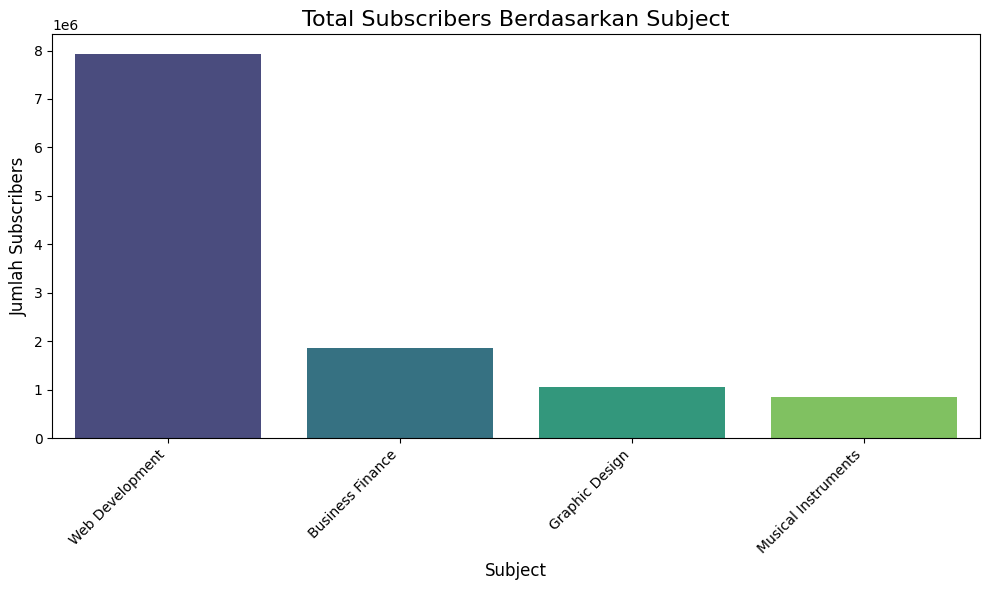

In [ ]:
subject_subscribers = df_cleaned.groupby('subject')['num_subscribers'].sum().reset_index()
subject_subscribers = subject_subscribers.sort_values(by='num_subscribers', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=subject_subscribers, x='subject', y='num_subscribers', palette='viridis')

# Menambahkan judul dan label
plt.title('Total Subscribers Berdasarkan Subject', fontsize=16)
plt.xlabel('Subject', fontsize=12)
plt.ylabel('Jumlah Subscribers', fontsize=12)

# Menampilkan chart
plt.xticks(rotation=45, ha='right')  # Rotasi label x-axis agar lebih terbaca
plt.tight_layout()  # Memperbaiki layout agar tidak terpotong
plt.show()

### 4.3 Distribusi harga kursus

Disini kita ingin melihat bagaimana penyebaran harga kursus yang ada pada Udemy, disini kita melihat penyeberan secara umum lalu lebih ke tingkat kesusahan dan juga berdasarkan subject.



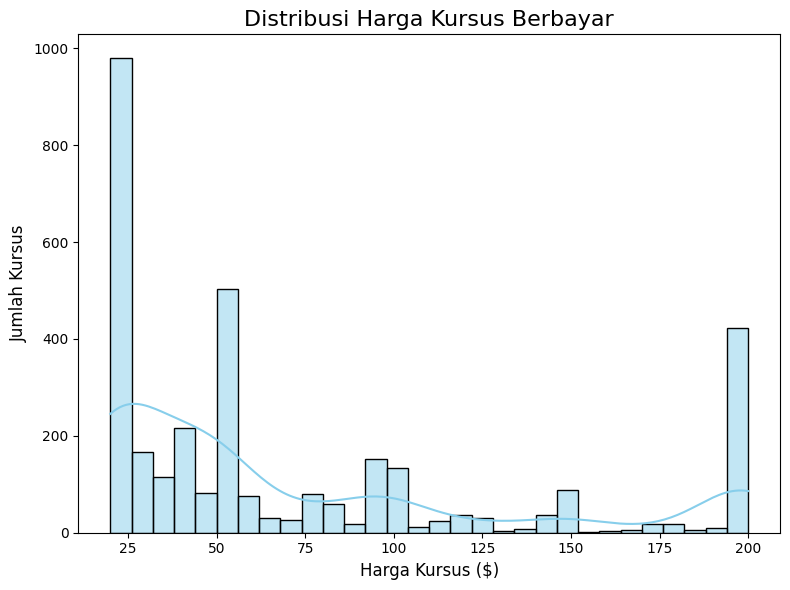

<ipython-input-25-b84855f26b1c>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_by_level, x='level', y='price', palette='viridis')


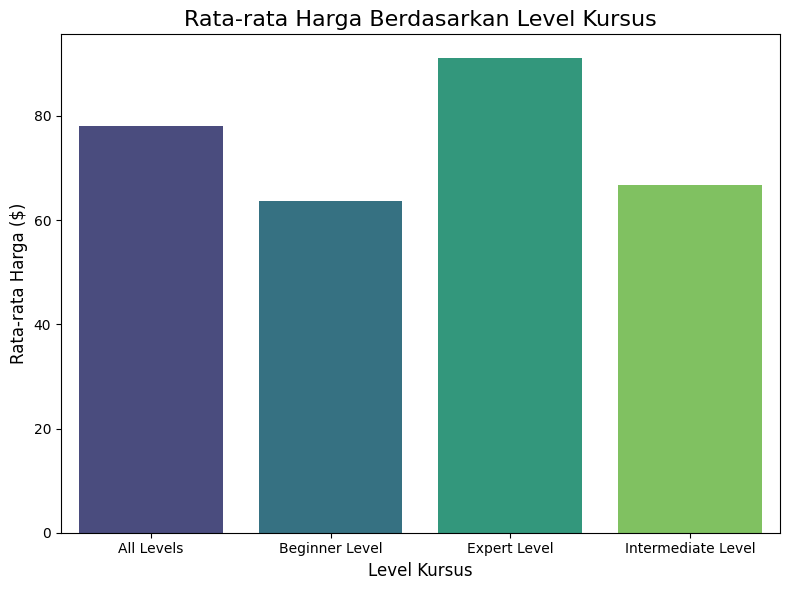

<ipython-input-25-b84855f26b1c>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_by_subject, x='subject', y='price', palette='viridis')


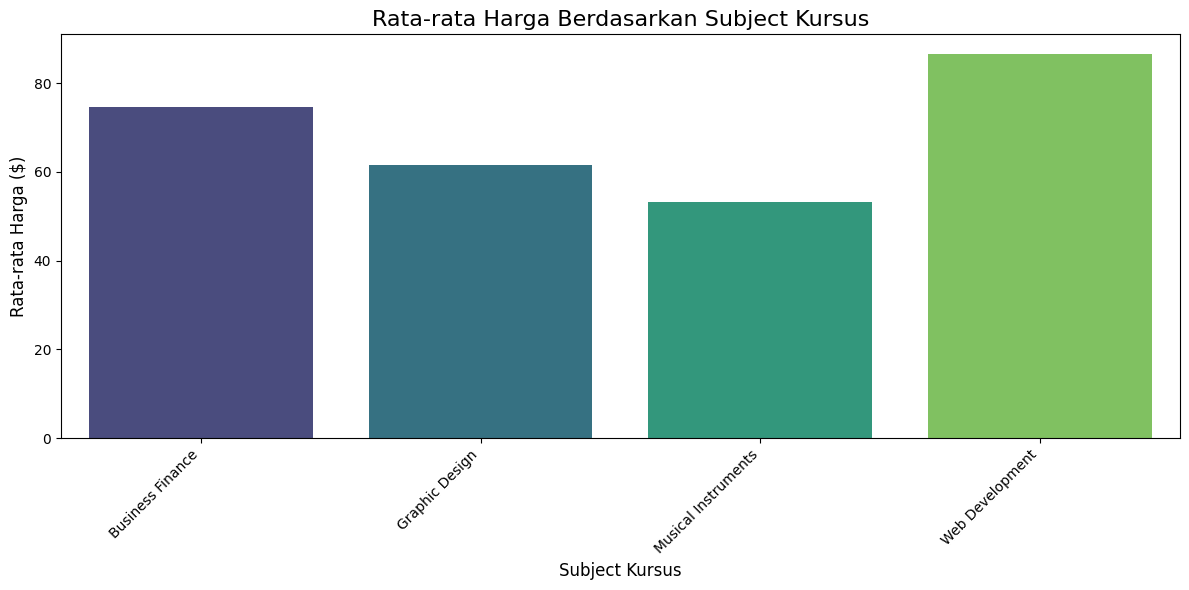

In [ ]:
paid_courses = df_cleaned[df_cleaned['is_paid'] == True]

# 1. Menganalisis distribusi harga kursus berbayar menggunakan histogram
plt.figure(figsize=(8, 6))
sns.histplot(paid_courses['price'], bins=30, kde=True, color='skyblue', edgecolor='black')

# Menambahkan judul dan label
plt.title('Distribusi Harga Kursus Berbayar', fontsize=16)
plt.xlabel('Harga Kursus ($)', fontsize=12)
plt.ylabel('Jumlah Kursus', fontsize=12)

# Menampilkan histogram
plt.tight_layout()
plt.show()

# 2. Menghitung rata-rata harga berdasarkan level dan subject
avg_price_by_level = paid_courses.groupby('level')['price'].mean().reset_index()
avg_price_by_subject = paid_courses.groupby('subject')['price'].mean().reset_index()

# 3. Visualisasi perbandingan rata-rata harga berdasarkan level
plt.figure(figsize=(8, 6))
sns.barplot(data=avg_price_by_level, x='level', y='price', palette='viridis')

# Menambahkan judul dan label
plt.title('Rata-rata Harga Berdasarkan Level Kursus', fontsize=16)
plt.xlabel('Level Kursus', fontsize=12)
plt.ylabel('Rata-rata Harga ($)', fontsize=12)

# Menampilkan bar chart
plt.tight_layout()
plt.show()

# 4. Visualisasi perbandingan rata-rata harga berdasarkan subject
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_price_by_subject, x='subject', y='price', palette='viridis')

# Menambahkan judul dan label
plt.title('Rata-rata Harga Berdasarkan Subject Kursus', fontsize=16)
plt.xlabel('Subject Kursus', fontsize=12)
plt.ylabel('Rata-rata Harga ($)', fontsize=12)

# Menampilkan bar chart
plt.xticks(rotation=45, ha='right')  # Rotasi label agar lebih terbaca
plt.tight_layout()
plt.show()

Dari hasilnya kita bisa lihat kursus dengan range harga sekitar $20 - $25 memiliki jumlah hampir 1000. Sedangkan yang harga-harga lainnya jumlahnya sangat rendah. Hanya di harga $200 yang memiliki jumlah diatas rata-rata, setelah yang tertinggi.

### 4.4 Distribusi durasi kursus

Dari data ini kita ingin melihat bagaimana penyebaran durasi kursusnya. Kita ingin mengetahui berapa jumlah kursus yang memiliki durasi.

Text(0, 0.5, 'Jumlah Kursus')

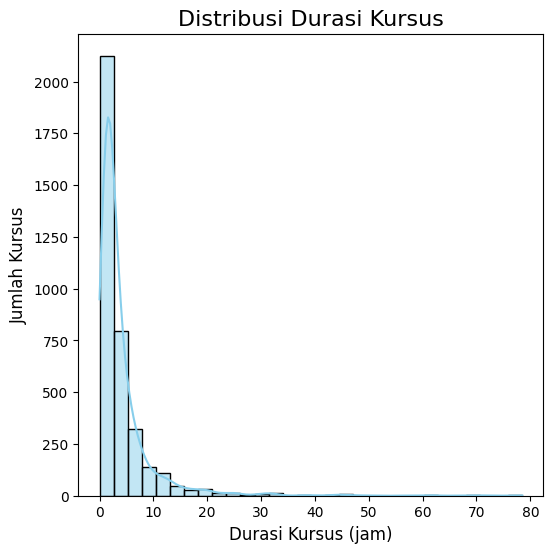

In [ ]:
course_duration = df_cleaned['content_duration']

plt.figure(figsize=(6, 6))
sns.histplot(data=course_duration, bins=30, kde=True, color='skyblue', edgecolor='black')

# Menambahkan judul dan label
plt.title('Distribusi Durasi Kursus', fontsize=16)
plt.xlabel('Durasi Kursus (jam)', fontsize=12)
plt.ylabel('Jumlah Kursus', fontsize=12)


### 4.5 Rata rata durasi kursus dalam setiap subject

Dari sini kita ingin melihat subject apa yang memiliki durasi terbanyak.

<ipython-input-17-960a8945c504>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_subject_duration, x="subject", y="content_duration",  palette='viridis')


Text(0, 0.5, 'Rata-rata durasi kursus')

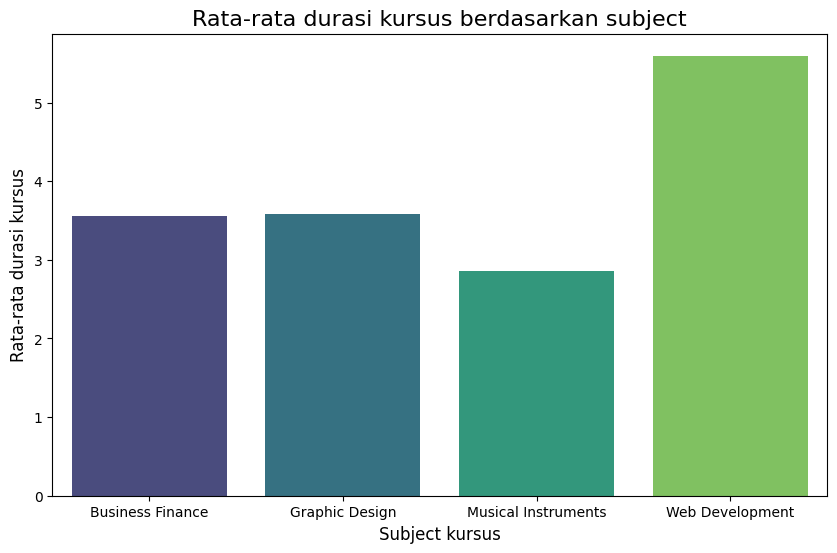

In [ ]:
avg_subject_duration = df_cleaned.groupby('subject')['content_duration'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=avg_subject_duration, x="subject", y="content_duration",  palette='viridis')

plt.title("Rata-rata durasi kursus berdasarkan subject", fontsize=16)
plt.xlabel("Subject kursus", fontsize=12)
plt.ylabel("Rata-rata durasi kursus", fontsize=12)


### 4.6 Melihat Korelasi antara durasi kursus dengan harga kursus

Setelah mengetahui informasi harga dan durasi kursus. Kita ingin melihat apakah ada korelasi antara harga dengan durasi kursus.

Text(0, 0.5, ' Harga kursus ($)')

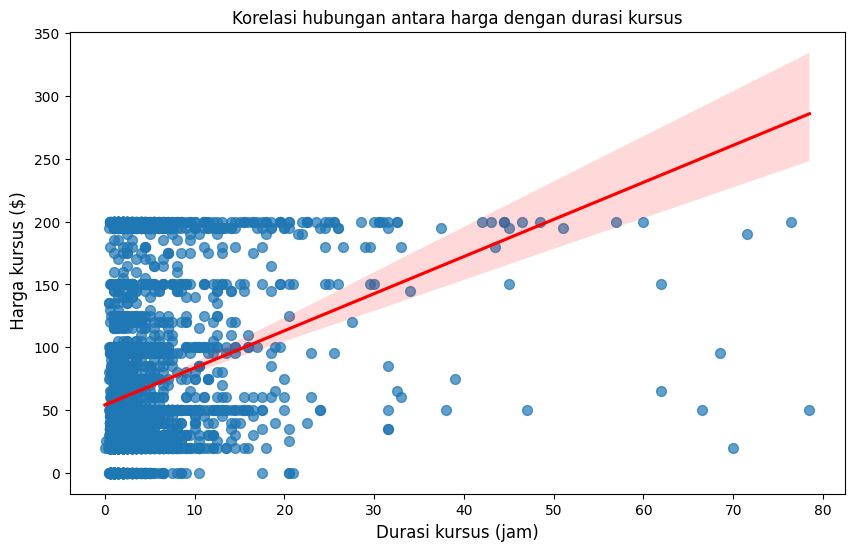

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(x='content_duration', y='price', data=df_cleaned, scatter_kws={'s': 50, 'alpha': 0.7}, line_kws={'color': 'red'})

plt.title("Korelasi hubungan antara harga dengan durasi kursus")
plt.xlabel("Durasi kursus (jam)", fontsize=12)
plt.ylabel(" Harga kursus ($)", fontsize=12)

Berdasarkan hasilnya harga dengan durasi kursus memiliki korelasi positif. Berarti hal ini menunjukkan jika kursus memiliki durasi yang panjang, maka harga dari kursus juga relatif lebih mahal.

### 4.7 Perbandingan antara kursus gratis dengan berbayar

Kita ingin melihat bagaimana performa dari kursus gratis dan kursus berbayar. Apakah kursus gratis memiliki banyak subscribers atau sebaliknya?

<ipython-input-19-b07ee272b887>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cleaned, x="is_paid", y="num_subscribers",  palette='viridis')


Text(0, 0.5, 'Jumlah subscriber')

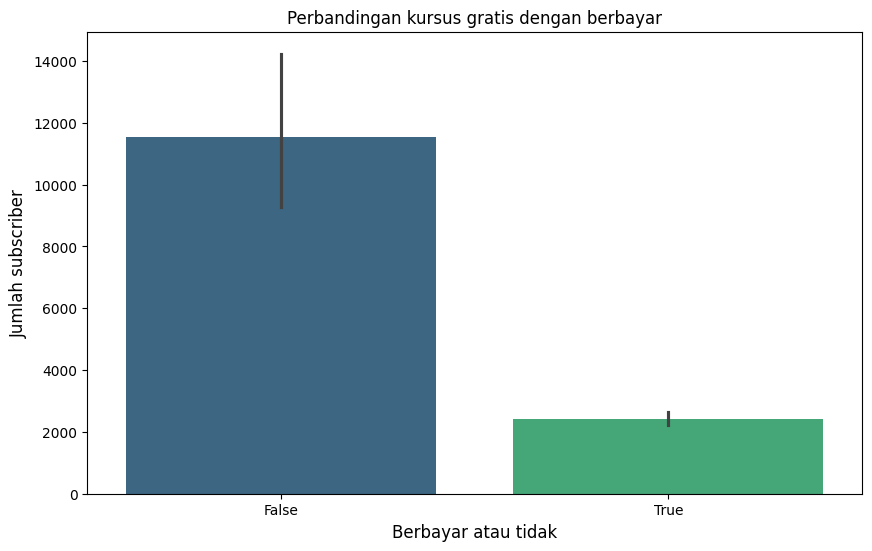

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_cleaned, x="is_paid", y="num_subscribers",  palette='viridis')
plt.title("Perbandingan kursus gratis dengan berbayar")
plt.xlabel("Berbayar atau tidak", fontsize=12)
plt.ylabel("Jumlah subscriber", fontsize=12)


Berdasarkan hasilnya kursus gratis memiliki subscribers lebih banyak.

### 4.8 Perbandingan Review kursus berbayar dengan gratis

Dari analisis sebelumnya kita sudah mengetahui bahwa subscribers dari kursus gratis lebih banyak. Bagaimana dengan reviews yang diberikan?

<ipython-input-20-bdd03f2a6f80>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cleaned, x="is_paid", y="num_reviews",  palette='viridis')


Text(0, 0.5, 'Jumlah review')

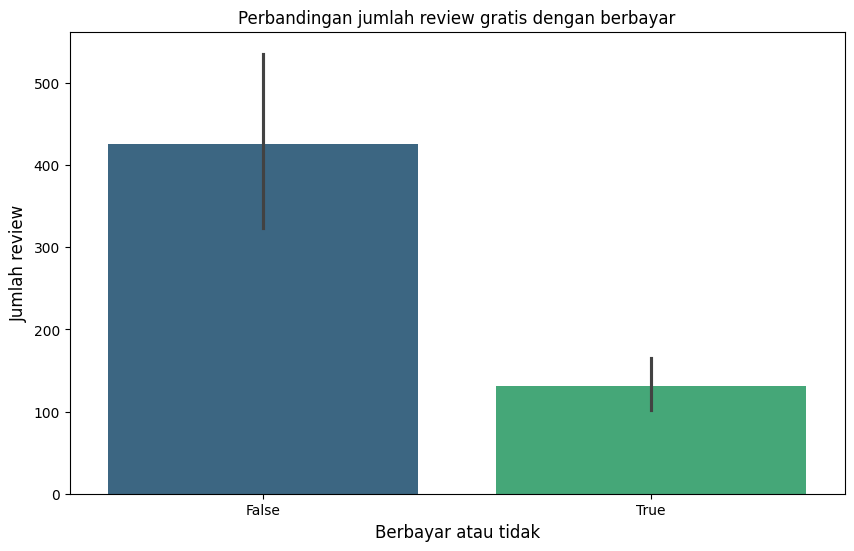

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_cleaned, x="is_paid", y="num_reviews",  palette='viridis')
plt.title("Perbandingan jumlah review gratis dengan berbayar")
plt.xlabel("Berbayar atau tidak", fontsize=12)
plt.ylabel("Jumlah review", fontsize=12)

Berdasarkan hasilnya kursus gratis memiliki review yang lebih banyak.

### 4.9 Korelasi antara jumlah review dan harga kursus

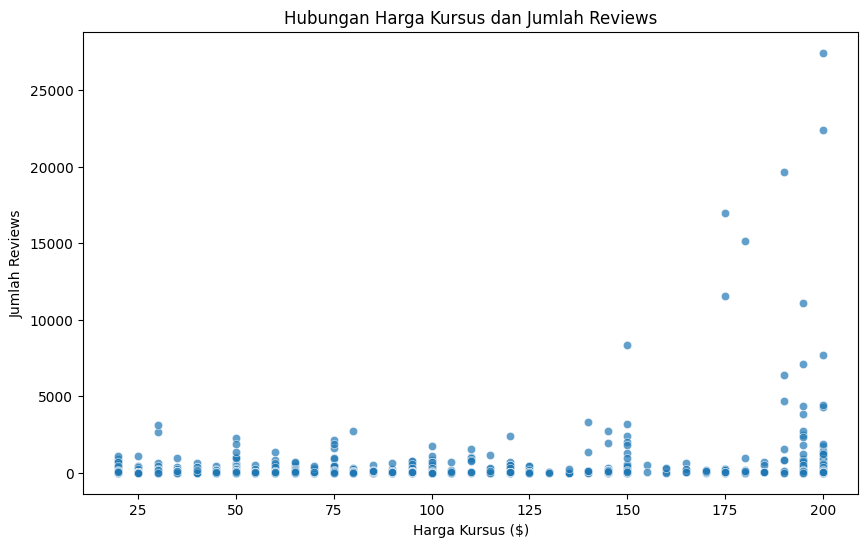

Korelasi antara harga dan jumlah reviews: 
                price  num_reviews
price        1.000000     0.159097
num_reviews  0.159097     1.000000


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=paid_courses, x='price', y='num_reviews', alpha=0.7)
plt.title('Hubungan Harga Kursus dan Jumlah Reviews')
plt.xlabel('Harga Kursus ($)')
plt.ylabel('Jumlah Reviews')
plt.show()

correlation = paid_courses[['price', 'num_reviews']].corr()
print(f"Korelasi antara harga dan jumlah reviews: ")
print(correlation)

Dari hasi yang ditunjukan hubungan korelasinya memiliki nilai koefisien **0.159**. Berarti hubungan korelasi antara harga dan jumlah review sangat lemah.

### 4.10 Analisis tahun dan bulan dengan kursus terbit terbanyak

Mengidentifikasi berapa banyak kursus yang terbit tiap bulan per tahunnya.

<ipython-input-27-1aa0669e797c>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=courses_per_year.index, y=courses_per_year.values, palette='viridis')


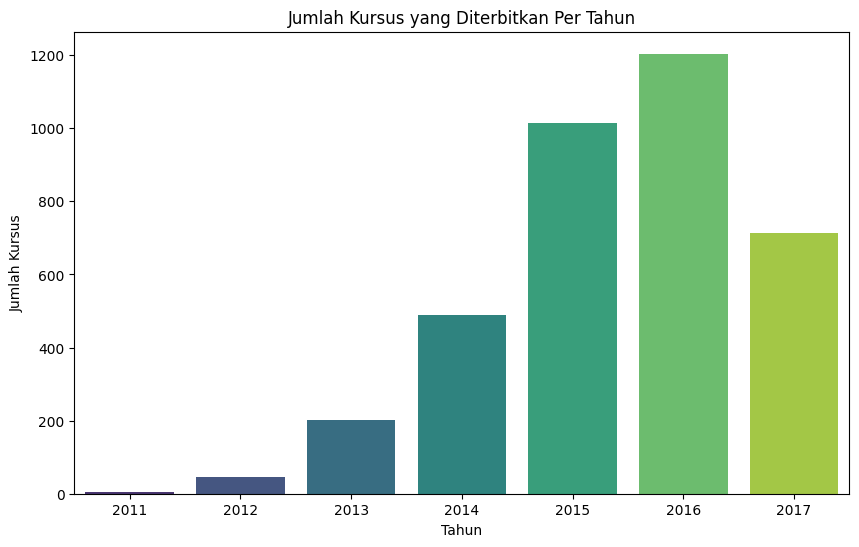

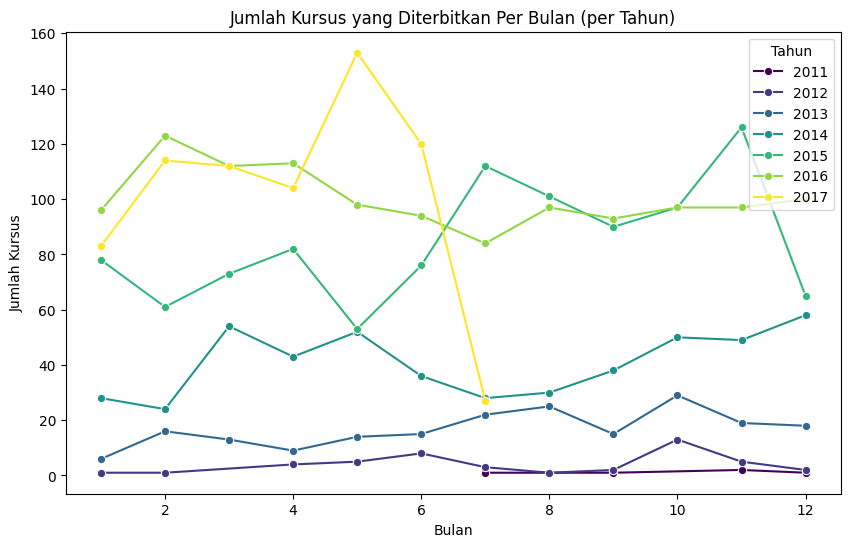

In [ ]:
#Filter berdasarkan tahun
courses_per_year = df_cleaned['year'].value_counts().sort_index()

#Filter berdasarkan bulan
courses_per_month = df_cleaned.groupby(['year', 'month']).size().reset_index(name='count')

#Visualisasi tahun
plt.figure(figsize=(10,6))
sns.barplot(x=courses_per_year.index, y=courses_per_year.values, palette='viridis')
plt.title('Jumlah Kursus yang Diterbitkan Per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Kursus')
plt.show()

#Visualisasi bulan
plt.figure(figsize=(10, 6))
sns.lineplot(data=courses_per_month, x='month', y='count', hue='year', marker='o', palette='viridis')
plt.title('Jumlah Kursus yang Diterbitkan Per Bulan (per Tahun)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Kursus')
plt.legend(title='Tahun')
plt.show()

### 4.11 Perubahan subscribers dan reviews dari waktu ke waktu

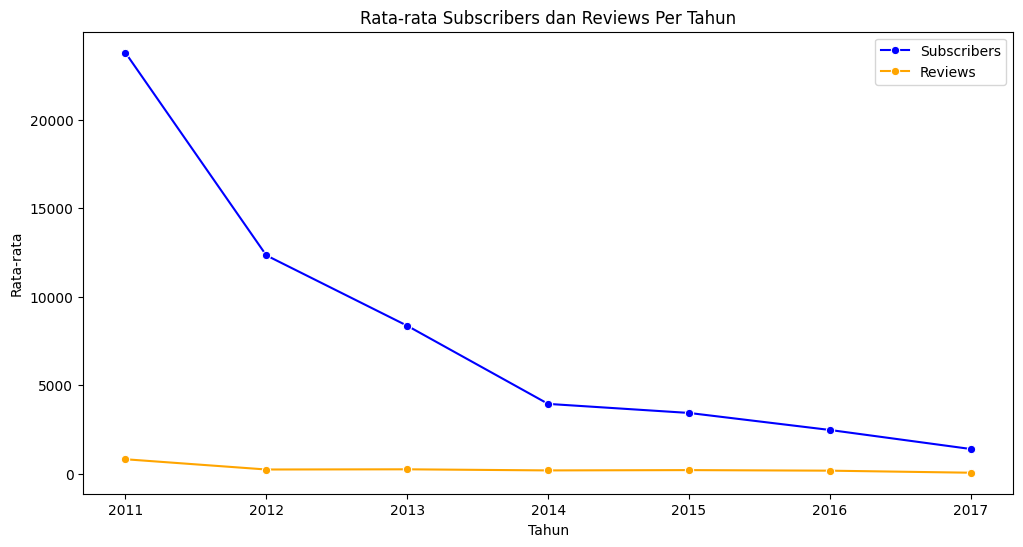

In [ ]:
subscribers_reviews_by_year = df_cleaned.groupby('year')[['num_subscribers','num_reviews']].mean().reset_index()

#Visualisasi lineplot
plt.figure(figsize=(12, 6))
sns.lineplot(data=subscribers_reviews_by_year, x='year', y='num_subscribers', marker='o', label='Subscribers', color='blue')
sns.lineplot(data=subscribers_reviews_by_year, x='year', y='num_reviews', marker='o', label='Reviews', color='orange')
plt.title('Rata-rata Subscribers dan Reviews Per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata')
plt.legend()
plt.show()

### 4.12 Analisis Revenue per tahun

<ipython-input-29-650b2ad4fea3>:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=revenue_by_year, x="year", y="revenue", marker='o', palette='viridis')


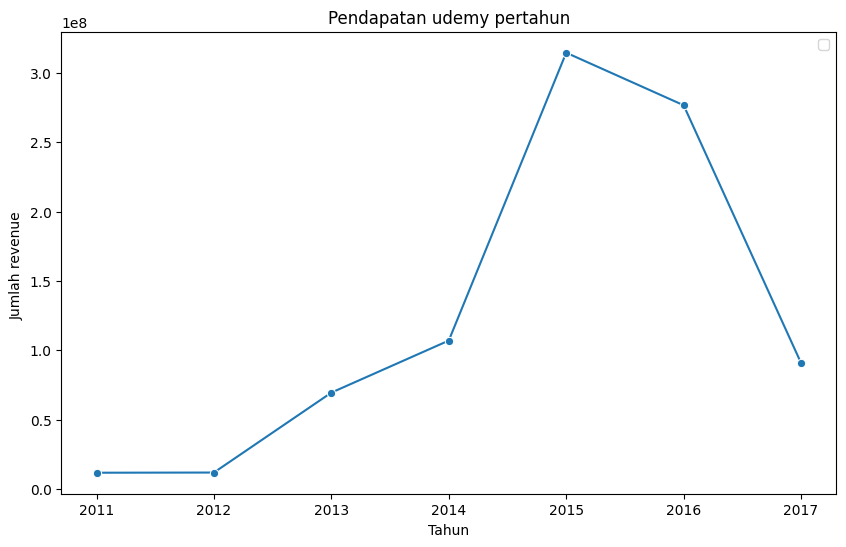

In [ ]:
revenue_by_year = df_cleaned.groupby('year')['revenue'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=revenue_by_year, x="year", y="revenue", marker='o', palette='viridis')
plt.title('Pendapatan udemy pertahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah revenue ')
plt.legend()
plt.show()

### 4.13 Analisis korelasi dengan semua field

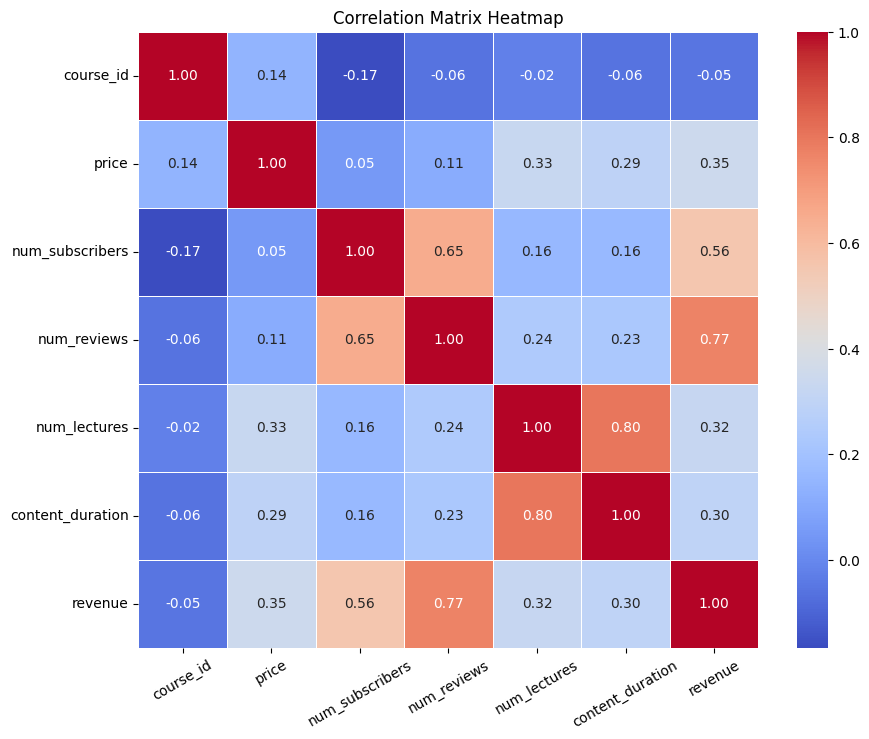

In [ ]:
correlation_df = df_cleaned.select_dtypes(include=['float64', 'int64'])

corr_matrix = correlation_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.7, fmt=".2f")

plt.title('Correlation Matrix Heatmap')
plt.xticks(rotation= 30)

plt.show()

Berdasarkan heatmap diatass ada beberapa korelasi yang tinggi antar beberapa kolom

**Revenue**
- Revenue memiliki hubungan yang kuat dengan ```num_subcriber``` dan ```num_reviews``` yang mengindikasikan kursusu dengan sucsriber dan review yang tinggi pendapatan dari kursus itu juga tinggi.

**Duration dan Lecturer**
- Durasi dan lecturer juga memiliki korelasi yang sangat tinggi, lecturer yang banyak memiliki durasi konten yang sangat tinggi juga.